# YTL Power (6742.KL) 5-Day Swing Trading Signal Prediction with XGBoost
### Using FBM KLCI (Top 30 Malaysian companies index) as a market-context feature & Macro Regime Features

This notebook builds a **3-class swing classifier** that predicts a 5-day trading action for **YTL Power (6742.KL)**:

| Class | Meaning | Trigger (5-Day Horizon) |
|---|---|---|
| `0` | **STILL** (Hold) | 5-day return stays inside neutral band `[-1.5%, +1.5%]` |
| `1` | **UP** (Buy)  | 5-day return is $> +1.5\%$ |
| `2` | **DOWN** (Sell) | 5-day return is $< -1.5\%$ |

using:
- YTL Power's own OHLCV-derived pruned technical & macro-regime features (momentum, 200-day trend, 52-week high breakout, volatility, volume)
- FBM KLCI (`^KLSE`) market-context and relative-strength alpha features

**Structure of this notebook:**
1. Data Cleaning
2. Time-Series Data Split (Train : Valid : Test = 6 : 2 : 2 with 5-Day Embargo Purge)
3. Advanced Feature Engineering (Orthogonal Momentum, Breakout & Macro-Regime Signals)
4. XGBoost Hyperparameter & Threshold Tuning (Optuna)
5. Baseline Comparison
6. Full Model Evaluation Results
7. Test (Production) Score
8. Mock Trading Simulation (5-Day Swing Holding Period with Realistic Long/Cash & Long/Short Modes)

## 0. Setup & Installs

Install/import all required libraries. `ta` is used for technical-analysis indicators, `xgboost` for the classifier, and `optuna` for Bayesian hyperparameter optimization.

In [84]:
import warnings
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import ta
import optuna
import yfinance as yf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [85]:
# --- Config ---
YTL_POWER_TICKER = "6742.KL"  # YTL Power International on Bursa Malaysia
KLCI_TICKER = "^KLSE"        # FTSE Bursa Malaysia KLCI benchmark index

START_DATE = "2012-01-01"   # 2012 covers multi-year consolidation, COVID crash, & the 2023-2024 AI rally
END_DATE = None             # None = up to today

print(f"YTL Power ticker : {YTL_POWER_TICKER}")
print(f"FBM KLCI ticker  : {KLCI_TICKER}")

YTL Power ticker : 6742.KL
FBM KLCI ticker  : ^KLSE


## Download Raw Data

We pull daily OHLCV data for both YTL Power and the FBM KLCI index with `auto_adjust=True` so that all prices (Open, High, Low, Close) are split- and dividend-adjusted. We defensively flatten any MultiIndex column headers returned by `yfinance`.

In [86]:
ytl_power_raw = yf.download(
    YTL_POWER_TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False
)
klci_raw = yf.download(
    KLCI_TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False
)

# Flatten MultiIndex columns down to single strings ('Open', 'High', 'Low', 'Close', 'Volume')
if isinstance(ytl_power_raw.columns, pd.MultiIndex):
    ytl_power_raw.columns = ytl_power_raw.columns.get_level_values(0)
if isinstance(klci_raw.columns, pd.MultiIndex):
    klci_raw.columns = klci_raw.columns.get_level_values(0)

print("YTL Power shape:", ytl_power_raw.shape)
print("KLCI shape     :", klci_raw.shape)
ytl_power_raw.tail()

YTL Power shape: (3627, 5)
KLCI shape     : (3604, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-09-17,5.66,5.81,5.49,5.53,23667400
2026-09-18,5.58,5.71,5.53,5.66,21634700
2026-09-21,5.89,6.00,5.57,5.58,22107100
2026-09-22,5.93,5.95,5.84,5.89,18112400
2026-09-23,5.91,5.98,5.87,5.93,12204400


## 1. Data Cleaning

Requirement: **drop rows that have null values in OHLCV**, for both YTL Power and the FBM KLCI series. We also drop non-trading rows where `Volume == 0`, and align both series on shared trading dates (inner join).

In [87]:
def clean_ohlcv(df, name):
    ohlcv_cols = ["Open", "High", "Low", "Close", "Volume"]
    before = len(df)
    df = df.copy()

    # Keep only rows where all OHLCV columns are present and non-null
    df = df.dropna(subset=ohlcv_cols)

    # Defensive: drop any rows where volume is 0 (non-trading / bad data)
    df = df[df["Volume"] > 0]

    after = len(df)
    print(
        f"[{name}] Dropped {before - after} rows with null/invalid OHLCV out of {before} total rows."
    )
    return df


ytl_power_clean = clean_ohlcv(ytl_power_raw, "YTL Power")
klci_clean = clean_ohlcv(klci_raw, "FBM KLCI")

# Align both series on shared trading dates (inner join)
common_dates = ytl_power_clean.index.intersection(klci_clean.index)
ytl_power_clean = ytl_power_clean.loc[common_dates].sort_index()
klci_clean = klci_clean.loc[common_dates].sort_index()

print(f"\nAligned shape (both series): {ytl_power_clean.shape}")
assert ytl_power_clean.isna().sum().sum() == 0, "Nulls remain in YTL Power OHLCV!"
assert klci_clean.isna().sum().sum() == 0, "Nulls remain in KLCI OHLCV!"
print("No nulls remain in either OHLCV dataset. ✅")

[YTL Power] Dropped 29 rows with null/invalid OHLCV out of 3627 total rows.
[FBM KLCI] Dropped 17 rows with null/invalid OHLCV out of 3604 total rows.

Aligned shape (both series): (3582, 5)
No nulls remain in either OHLCV dataset. ✅


## 2. Time-Series Data Split (Train : Valid : Test = 6 : 2 : 2)

Because financial prices are chronological time series, we split sequentially:
- **Train (60%)** — fit tree models (2012 through early 2020)
- **Valid (20%)** — hyperparameter tuning & threshold optimization
- **Test (20%)** — completely held out (2023 through today, capturing the AI super-cycle)

In [88]:
n = len(ytl_power_clean)
train_end_idx = int(n * 0.6)
valid_end_idx = int(n * 0.8)

train_dates = ytl_power_clean.index[:train_end_idx]
valid_dates = ytl_power_clean.index[train_end_idx:valid_end_idx]
test_dates = ytl_power_clean.index[valid_end_idx:]

print(f"Total rows : {n}")
print(
    f"Train      : {len(train_dates):>5} rows  ({train_dates.min().date()} -> {train_dates.max().date()})"
)
print(
    f"Valid      : {len(valid_dates):>5} rows  ({valid_dates.min().date()} -> {valid_dates.max().date()})"
)
print(
    f"Test (prod): {len(test_dates):>5} rows  ({test_dates.min().date()} -> {test_dates.max().date()})"
)
print(
    f"\nRatio check -> train: {len(train_dates) / n:.2%}, valid: {len(valid_dates) / n:.2%}, test: {len(test_dates) / n:.2%}"
)

Total rows : 3582
Train      :  2149 rows  (2012-01-03 -> 2020-11-04)
Valid      :   716 rows  (2020-11-05 -> 2023-10-12)
Test (prod):   717 rows  (2023-10-13 -> 2026-09-21)

Ratio check -> train: 59.99%, valid: 19.99%, test: 20.02%


## 3. Advanced Feature Engineering (14 Micro-Trimmed Orthogonal Signals)

To maximize signal purity for XGBoost and eliminate duplicate explanations in SHAP / LLM prompts, we pruned twin features (e.g. dropping `ret_std_10` in favor of `atr_14_ratio`, and dropping `volume_sma60_ratio` in favor of `volume_sma_ratio`), leaving **14 distinct, non-overlapping signals**:

1. **YTL Momentum & Acceleration:**
   - `rsi_14`: 14-day Relative Strength Index.
   - `macd_diff`: MACD histogram (momentum acceleration).
2. **YTL Trend Regimes:**
   - `price_to_sma20`: Pullback distance from 20-day trend.
   - `sma20_to_sma50`: Moving average slope.
   - `price_to_sma200`: Long-term distance from 200-day SMA (identifies macro structural bull runs).
   - `dist_to_52w_high`: Distance to 52-week rolling high (detects breakout momentum into all-time highs).
3. **Volatility & Trend Strength:**
   - `adx_14`: Trend strength intensity.
   - `atr_14_ratio`: Normalized Average True Range (`ATR(14) / Close`) — volatility breakout energy.
4. **Volume & Money Flow:**
   - `volume_sma_ratio`: 20-day short volume surge.
   - `cmf_20`: Chaikin Money Flow (`CMF(20)`) — measures institutional accumulation vs. distribution to filter false sell alarms.
5. **FBM KLCI Macro Market Context:**
   - `klci_price_to_sma200`: Broad market macro bull/bear regime.
   - `klci_macd_diff`: Broad market momentum acceleration.
6. **Relative Alpha (YTL vs. Market):**
   - `ytl_vs_klci_ret_5d`: 5-day alpha outperformance spread vs. FBM KLCI.
   - `ytl_vs_klci_rsi_diff`: Relative momentum spread.

In [89]:
def build_pruned_features(df, prefix=""):
    """Extracts 10 clean, non-redundant individual stock signals without collinear duplicates."""
    close = df["Close"]
    high = df["High"]
    low = df["Low"]
    volume = df["Volume"]

    feat = pd.DataFrame(index=df.index)

    # 1. Momentum & Acceleration
    feat["rsi_14"] = ta.momentum.RSIIndicator(close, window=14).rsi()
    macd = ta.trend.MACD(close)
    feat["macd_diff"] = macd.macd_diff()

    # 2. Trend & Regimes
    sma_20 = ta.trend.SMAIndicator(close, window=20).sma_indicator()
    sma_50 = ta.trend.SMAIndicator(close, window=50).sma_indicator()
    sma_200 = ta.trend.SMAIndicator(close, window=200).sma_indicator()
    feat["price_to_sma20"] = close / sma_20 - 1
    feat["sma20_to_sma50"] = sma_20 / sma_50 - 1
    feat["price_to_sma200"] = close / sma_200 - 1
    feat["dist_to_52w_high"] = close / close.rolling(252).max() - 1

    # 3. Volatility & Trend Strength (Keeping ATR ratio, dropped redundant ret_std_10)
    feat["adx_14"] = ta.trend.ADXIndicator(high, low, close, window=14).adx()
    feat["atr_14_ratio"] = ta.volatility.AverageTrueRange(high, low, close, window=14).average_true_range() / close

    # 4. Volume Surge & Money Flow (Keeping 20-day volume surge, dropped redundant 60-day)
    feat["volume_sma_ratio"] = volume / volume.rolling(20).mean() - 1
    feat["cmf_20"] = ta.volume.ChaikinMoneyFlowIndicator(high, low, close, volume, window=20).chaikin_money_flow()

    if prefix:
        feat = feat.add_prefix(prefix)

    return feat


ytl_feat = build_pruned_features(ytl_power_clean)
klci_feat = build_pruned_features(klci_clean, prefix="klci_")

print("YTL Power base features (10):", list(ytl_feat.columns))
print("KLCI base features     (10):", list(klci_feat.columns))

YTL Power base features (10): ['rsi_14', 'macd_diff', 'price_to_sma20', 'sma20_to_sma50', 'price_to_sma200', 'dist_to_52w_high', 'adx_14', 'atr_14_ratio', 'volume_sma_ratio', 'cmf_20']
KLCI base features     (10): ['klci_rsi_14', 'klci_macd_diff', 'klci_price_to_sma20', 'klci_sma20_to_sma50', 'klci_price_to_sma200', 'klci_dist_to_52w_high', 'klci_adx_14', 'klci_atr_14_ratio', 'klci_volume_sma_ratio', 'klci_cmf_20']


In [90]:
# Select only the 2 essential macro KLCI market-context indicators
klci_selected = klci_feat[["klci_price_to_sma200", "klci_macd_diff"]]

# Merge YTL Power features with market-context features
features = ytl_feat.join(klci_selected, how="inner")

# Relative-strength alpha features: YTL Power vs. FBM KLCI
ytl_ret = ytl_power_clean["Close"].pct_change()
klci_ret = klci_clean["Close"].pct_change()

features["ytl_vs_klci_ret_5d"] = (
    ytl_ret.rolling(5).mean() - klci_ret.rolling(5).mean()
)
features["ytl_vs_klci_rsi_diff"] = ytl_feat["rsi_14"] - klci_feat["klci_rsi_14"]

# Defensive: replace any infinite values with NaN
features = features.replace([np.inf, -np.inf], np.nan)

print(f"Final micro-trimmed feature matrix shape: {features.shape}")
print(f"Total features: {features.shape[1]}")
print("Feature list:", list(features.columns))
features.tail()

Final micro-trimmed feature matrix shape: (3582, 14)
Total features: 14
Feature list: ['rsi_14', 'macd_diff', 'price_to_sma20', 'sma20_to_sma50', 'price_to_sma200', 'dist_to_52w_high', 'adx_14', 'atr_14_ratio', 'volume_sma_ratio', 'cmf_20', 'klci_price_to_sma200', 'klci_macd_diff', 'ytl_vs_klci_ret_5d', 'ytl_vs_klci_rsi_diff']


,rsi_14,macd_diff,price_to_sma20,sma20_to_sma50,price_to_sma200,dist_to_52w_high,adx_14,atr_14_ratio,volume_sma_ratio,cmf_20,klci_price_to_sma200,klci_macd_diff,ytl_vs_klci_ret_5d,ytl_vs_klci_rsi_diff
Date,,,,,,,,,,,,,,
2026-09-14,66.290074,-0.033289,0.029358,0.145479,0.486968,-0.037288,49.241403,0.028974,-0.497551,0.313249,-0.001756,-3.969588,-0.002215,25.250387
2026-09-15,56.929571,-0.052760,-0.007118,0.146780,0.439024,-0.066102,47.586274,0.030197,-0.396347,0.261968,-0.012997,-4.779612,-0.005342,22.232857
2026-09-17,62.024945,-0.055442,0.013701,0.147546,0.474508,-0.040678,46.604373,0.031336,0.320919,0.233521,-0.015771,-5.290665,-0.000064,28.649076
2026-09-18,58.078582,-0.062013,-0.006676,0.148538,0.450291,-0.054237,45.692608,0.031819,0.204582,0.233184,-0.021297,-5.876057,-0.000755,27.294555
2026-09-21,66.873997,-0.045645,0.039167,0.151143,0.526486,-0.001695,45.856241,0.033206,0.182658,0.256252,-0.020629,-5.790061,0.009382,35.230671


### Target Variable — 3-Class Trading Signal (5-Day Swing Horizon)

We define a **3-class trading action** based on a **5-day forward return horizon** (1 calendar trading week):

- **`1` = UP (Buy)** → 5-day forward return $> +1.5\%$ (`UP_THRESHOLD`)
- **`2` = DOWN (Sell)** → 5-day forward return $< -1.5\%$ (`DOWN_THRESHOLD`)
- **`0` = STILL (Hold)** → 5-day forward return stays inside `[-1.5%, +1.5%]`

A 5-day horizon provides enough time for technical momentum setups to mature while overcoming short-term intra-week order-book noise.

In [91]:
# --- 5-Day Forward Horizon & Thresholds ---
HORIZON = 5  # 5 trading days forward (1 calendar week swing horizon)
UP_THRESHOLD = 0.015  # 5-day gain > +1.5% -> UP (Buy)
DOWN_THRESHOLD = -0.015  # 5-day drop < -1.5% -> DOWN (Sell)

LABEL_NAMES = {0: "STILL", 1: "UP", 2: "DOWN"}

# Forward H-day return: (Close[t + H] - Close[t]) / Close[t]
forward_return = (
    ytl_power_clean["Close"].shift(-HORIZON) / ytl_power_clean["Close"]
) - 1

target = pd.Series(
    0, index=ytl_power_clean.index, name="target_signal"
)  # default: 0 = STILL
target[forward_return > UP_THRESHOLD] = 1  # UP
target[forward_return < DOWN_THRESHOLD] = 2  # DOWN
target[forward_return.isna()] = (
    np.nan  # last H rows have no forward horizon -> undefined
)

dataset = features.join(target, how="inner")

# Drop rows with NaNs from rolling indicator warm-up periods
# and the last H rows where forward return is undefined
before = len(dataset)
dataset = dataset.replace([np.inf, -np.inf], np.nan).dropna()
dataset["target_signal"] = dataset["target_signal"].astype(int)
after = len(dataset)

print(
    f"Dropped {before - after} rows (indicator warm-up + last {HORIZON} horizon rows)."
)
print(f"Final modeling dataset shape: {dataset.shape}")

class_dist = (
    dataset["target_signal"]
    .value_counts(normalize=True)
    .rename("proportion")
    .sort_index()
)
class_dist.index = class_dist.index.map(LABEL_NAMES)
print(f"\nClass Distribution ({HORIZON}-Day Horizon):")
print(class_dist)

Dropped 256 rows (indicator warm-up + last 5 horizon rows).
Final modeling dataset shape: (3326, 15)

Class Distribution (5-Day Horizon):
target_signal
STILL    0.409802
UP       0.310283
DOWN     0.279916
Name: proportion, dtype: float64


### Apply the Train / Valid / Test Split with Embargo Purge Window

> **Preventing Forward-Label Leakage (Embargo / Purge):** Because our target is a **5-day forward return** (`shift(-HORIZON)`), the final rows of the training set would look forward into the validation set's price timeline if not purged. We enforce an **embargo purge gap of `HORIZON = 5` trading days** between Train and Valid, as well as between Valid and Test.

In [92]:
n_final = len(dataset)
train_end = int(n_final * 0.6)
valid_end = int(n_final * 0.8)

# Enforce an embargo/purge gap of HORIZON bars between splits to prevent forward-looking label leakage
train_df = dataset.iloc[: train_end - HORIZON]
valid_df = dataset.iloc[train_end : valid_end - HORIZON]
test_df = dataset.iloc[valid_end :]

feature_cols = [c for c in dataset.columns if c != "target_signal"]

X_train, y_train = train_df[feature_cols], train_df["target_signal"]
X_valid, y_valid = valid_df[feature_cols], valid_df["target_signal"]
X_test,  y_test  = test_df[feature_cols],  test_df["target_signal"]

# --- Compute class balance weights ---
sample_weights_train = compute_sample_weight("balanced", y_train)
sample_weights_valid = compute_sample_weight("balanced", y_valid)

print(f"Train: {X_train.shape}  ({train_df.index.min().date()} -> {train_df.index.max().date()}) [Purged last {HORIZON} bars before Valid]")
print(f"Valid: {X_valid.shape}  ({valid_df.index.min().date()} -> {valid_df.index.max().date()}) [Purged last {HORIZON} bars before Test]")
print(f"Test : {X_test.shape}  ({test_df.index.min().date()} -> {test_df.index.max().date()})  <- production hold-out")

def class_balance_str(y):
    counts = y.value_counts(normalize=True).sort_index()
    return ", ".join(f"{LABEL_NAMES[k]}: {v:.1%}" for k, v in counts.items())

print(f"\nTrain class balance -> {class_balance_str(y_train)}")
print(f"Valid class balance -> {class_balance_str(y_valid)}")
print(f"Test  class balance -> {class_balance_str(y_test)}")

Train: (1990, 14)  (2013-01-10 -> 2021-03-19) [Purged last 5 bars before Valid]
Valid: (660, 14)  (2021-03-29 -> 2023-12-11) [Purged last 5 bars before Test]
Test : (666, 14)  (2023-12-19 -> 2026-09-11)  <- production hold-out

Train class balance -> STILL: 46.4%, UP: 26.5%, DOWN: 27.1%
Valid class balance -> STILL: 44.8%, UP: 33.6%, DOWN: 21.5%
Test  class balance -> STILL: 20.9%, UP: 41.7%, DOWN: 37.4%


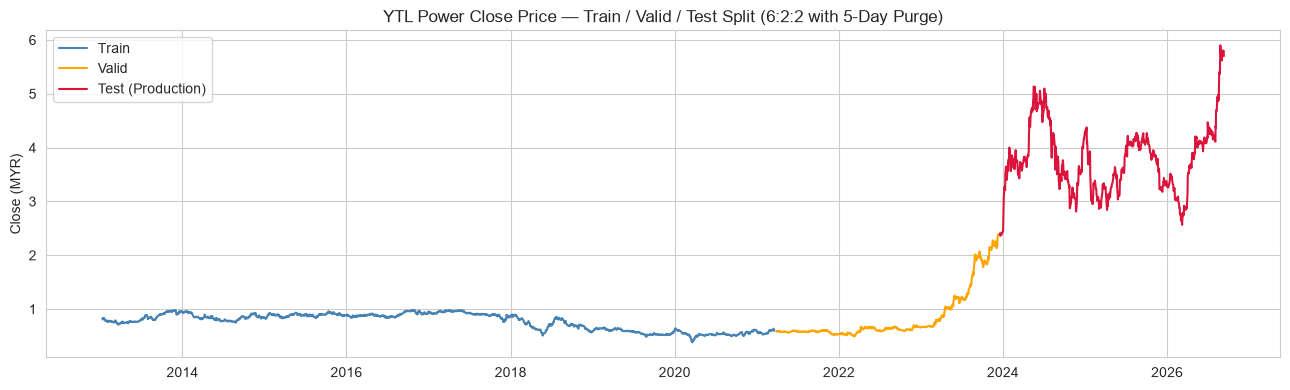

In [93]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(
    train_df.index,
    ytl_power_clean.loc[train_df.index, "Close"],
    label="Train",
    color="steelblue",
)
ax.plot(
    valid_df.index,
    ytl_power_clean.loc[valid_df.index, "Close"],
    label="Valid",
    color="orange",
)
ax.plot(
    test_df.index,
    ytl_power_clean.loc[test_df.index, "Close"],
    label="Test (Production)",
    color="crimson",
)
ax.set_title("YTL Power Close Price — Train / Valid / Test Split (6:2:2 with 5-Day Purge)")
ax.set_ylabel("Close (MYR)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. XGBoost Hyperparameter & Threshold Tuning (Optuna)

We use Bayesian optimization via **Optuna** to tune:
- Tree regularization: `learning_rate`, `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `gamma`, `reg_alpha`, `reg_lambda`
- **Inference policy threshold:** `confidence_threshold` (jointly optimized to maximize Validation Macro F1 under the exact same decision rule used in production).

In [94]:
# Suppress verbose Optuna logging output per trial
optuna.logging.set_verbosity(optuna.logging.WARNING)

MAX_ESTIMATORS = 500
EARLY_STOPPING_ROUNDS = 25


def predict_with_confidence(proba_matrix, up_thresh=0.38, down_thresh=0.45):
    """Asymmetric confidence decision rule:

    col 0 = P(STILL), col 1 = P(UP), col 2 = P(DOWN)
    - Enter UP (1) if P(UP) >= up_thresh and P(UP) > P(DOWN)
    - Enter DOWN (2) only if P(DOWN) >= down_thresh and P(DOWN) > P(UP) (higher proof to eliminate false sell alarms)
    - Otherwise -> STILL (0) (sit out in cash)
    """
    preds = np.zeros(len(proba_matrix), dtype=int)
    p_up = proba_matrix[:, 1]
    p_down = proba_matrix[:, 2]

    up_mask = (p_up >= up_thresh) & (p_up > p_down)
    down_mask = (p_down >= down_thresh) & (p_down > p_up)

    preds[up_mask] = 1
    preds[down_mask] = 2
    return preds


def objective(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "n_estimators": MAX_ESTIMATORS,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        # --- Search Space ---
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.08),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 35),
        "subsample": trial.suggest_float("subsample", 0.65, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "gamma": trial.suggest_float("gamma", 0.05, 0.8),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.05, 3.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0, log=True),
    }

    # Jointly tune asymmetric confidence thresholds for UP and DOWN
    up_threshold = trial.suggest_float("up_threshold", 0.33, 0.44)
    down_threshold = trial.suggest_float("down_threshold", 0.35, 0.48)

    model = XGBClassifier(**params)
    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_valid, y_valid)],
        sample_weight_eval_set=[sample_weights_valid],
        verbose=False,
    )

    valid_prob = model.predict_proba(X_valid)
    valid_pred = predict_with_confidence(valid_prob, up_thresh=up_threshold, down_thresh=down_threshold)

    # Optimize for Validation Macro F1 under the exact asymmetric confidence decision rule
    return f1_score(y_valid, valid_pred, average="macro", zero_division=0)


print("Running Optuna Bayesian Optimization with Asymmetric Threshold Tuning (50 trials)...")
study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=50)

best_params = study.best_params
print("\n" + "=" * 60)
print(f"OPTUNA BEST VALID MACRO F1: {study.best_value:.4f}")
print("=" * 60)
for k, v in best_params.items():
    print(
        f"  {k:>22}: {v:.4f}"
        if isinstance(v, float)
        else f"  {k:>22}: {v}"
    )

Running Optuna Bayesian Optimization with Asymmetric Threshold Tuning (50 trials)...

OPTUNA BEST VALID MACRO F1: 0.3873
           learning_rate: 0.0178
               max_depth: 3
        min_child_weight: 33
               subsample: 0.7403
        colsample_bytree: 0.7171
                   gamma: 0.2035
               reg_alpha: 0.0727
              reg_lambda: 1.0259
            up_threshold: 0.3482
          down_threshold: 0.3801


In [95]:
# Optuna training Results 
trials_df = study.trials_dataframe()

param_cols = [c for c in trials_df.columns if c.startswith("params_")]
display_df = trials_df[["number", "value"] + param_cols].copy()
display_df.rename(columns={"number": "trial", "value": "valid_macro_f1"}, inplace=True)
display_df.columns = [c.replace("params_", "") for c in display_df.columns]

tuning_results_df = (
    display_df.sort_values("valid_macro_f1", ascending=False).reset_index(drop=True)
)

print(f"Top 10 Optuna Trials out of {len(trials_df)}:")
tuning_results_df.head(10)

Top 10 Optuna Trials out of 50:


,trial,valid_macro_f1,colsample_bytree,down_threshold,gamma,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,subsample,up_threshold
0,33,0.387328,0.717071,0.380064,0.203543,0.017823,3,33,0.072700,1.025911,0.740306,0.348203
1,48,0.384875,0.637413,0.380156,0.275126,0.020970,3,34,0.064745,1.420053,0.688670,0.348749
2,32,0.384044,0.647283,0.378891,0.269258,0.023300,3,35,0.053027,1.086286,0.708306,0.346519
3,31,0.383458,0.663461,0.392025,0.102566,0.035696,3,35,0.069642,1.161174,0.719968,0.351199
4,28,0.379924,0.662142,0.379059,0.337566,0.021276,3,35,0.197635,1.658716,0.668961,0.356067
5,42,0.379714,0.619046,0.399850,0.190070,0.021567,3,35,0.055353,0.795144,0.705248,0.334940
6,49,0.379649,0.691581,0.397909,0.280968,0.020186,3,35,0.057360,1.530922,0.709877,0.347891
7,37,0.379081,0.638778,0.397137,0.197305,0.015269,3,34,0.064443,0.819663,0.695965,0.335970
8,29,0.372878,0.695274,0.379346,0.276044,0.020813,3,34,0.133547,1.397362,0.736664,0.339947
9,39,0.368933,0.641874,0.350630,0.165910,0.027370,3,35,0.053173,0.798342,0.676016,0.330132


### Refit the Final Model

We refit `XGBClassifier` with the optimal hyperparameters, extracting `confidence_threshold` for downstream inference.

In [96]:
# Separate tree parameters from decision-threshold parameters
xgb_best_params = {k: v for k, v in best_params.items() if k not in ["up_threshold", "down_threshold"]}
UP_CONF_THRESHOLD = best_params.get("up_threshold", 0.38)
DOWN_CONF_THRESHOLD = best_params.get("down_threshold", 0.45)

final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_estimators=MAX_ESTIMATORS,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    **xgb_best_params,
)

final_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_valid, y_valid)],
    sample_weight_eval_set=[sample_weights_valid],
    verbose=False,
)

best_n_estimators = getattr(final_model, "best_iteration", MAX_ESTIMATORS)
print("Final model refit complete.")
print(f"Optimal boosting rounds (trees) : {best_n_estimators}")
print(f"Optimal UP confidence threshold  : {UP_CONF_THRESHOLD:.4f}")
print(f"Optimal DOWN confidence threshold: {DOWN_CONF_THRESHOLD:.4f}")

Final model refit complete.
Optimal boosting rounds (trees) : 71
Optimal UP confidence threshold  : 0.3482
Optimal DOWN confidence threshold: 0.3801


## 5. Baseline Comparison

We compare against the naive **majority-class baseline** to verify that the model adds directional value.

In [97]:
majority_class = int(y_train.mode()[0])
majority_class_name = LABEL_NAMES[majority_class]
print(
    f"Majority class in training data: '{majority_class_name}' ({(y_train == majority_class).mean():.2%} of train rows)"
)

baseline_predictions = np.full(len(y_test), majority_class, dtype=int)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(
    f"\nBaseline (always predict '{majority_class_name}') — Test accuracy: {baseline_accuracy:.4f}"
)
print(
    f"Baseline accuracy on Train: {accuracy_score(y_train, np.full(len(y_train), majority_class, dtype=int)):.4f}"
)
print(
    f"Baseline accuracy on Valid: {accuracy_score(y_valid, np.full(len(y_valid), majority_class, dtype=int)):.4f}"
)

Majority class in training data: 'STILL' (46.38% of train rows)

Baseline (always predict 'STILL') — Test accuracy: 0.2087
Baseline accuracy on Train: 0.4638
Baseline accuracy on Valid: 0.4485


## 6. Full Model Evaluation Results

Comprehensive evaluation across Train, Valid, and Test sets: accuracy, precision, recall, F1, ROC-AUC, confusion matrices, and feature importance.

In [98]:
# --- Asymmetric Confidence Thresholding & Prediction ---
print(f"Applying Asymmetric Thresholds -> UP: {UP_CONF_THRESHOLD:.4f}, DOWN: {DOWN_CONF_THRESHOLD:.4f}")

# Probabilities for all splits
train_prob = final_model.predict_proba(X_train)
valid_prob = final_model.predict_proba(X_valid)
test_prob = final_model.predict_proba(X_test)

# Apply asymmetric confidence thresholding
train_pred = predict_with_confidence(train_prob, up_thresh=UP_CONF_THRESHOLD, down_thresh=DOWN_CONF_THRESHOLD)
valid_pred = predict_with_confidence(valid_prob, up_thresh=UP_CONF_THRESHOLD, down_thresh=DOWN_CONF_THRESHOLD)
test_pred = predict_with_confidence(test_prob, up_thresh=UP_CONF_THRESHOLD, down_thresh=DOWN_CONF_THRESHOLD)


# Evaluate
def evaluate(y_true, pred, prob, split_name):
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, pred),
        "precision_macro": precision_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(y_true, pred, average="macro", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_score(
            y_true, prob, multi_class="ovr", average="macro"
        ),
    }


train_metrics = evaluate(y_train, train_pred, train_prob, "Train")
valid_metrics = evaluate(y_valid, valid_pred, valid_prob, "Valid")
test_metrics = evaluate(y_test, test_pred, test_prob, "Test (Production)")

results_summary = pd.DataFrame([train_metrics, valid_metrics, test_metrics]).set_index("split")

print("=== EVALUATION WITH ASYMMETRIC CONFIDENCE THRESHOLDING ===")
results_summary.round(4)

Applying Asymmetric Thresholds -> UP: 0.3482, DOWN: 0.3801
=== EVALUATION WITH ASYMMETRIC CONFIDENCE THRESHOLDING ===


,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_ovr_macro
split,,,,,
Train,0.5879,0.6196,0.5435,0.5484,0.7654
Valid,0.4106,0.3871,0.3881,0.3873,0.5757
Test (Production),0.3754,0.3545,0.3556,0.3544,0.5199


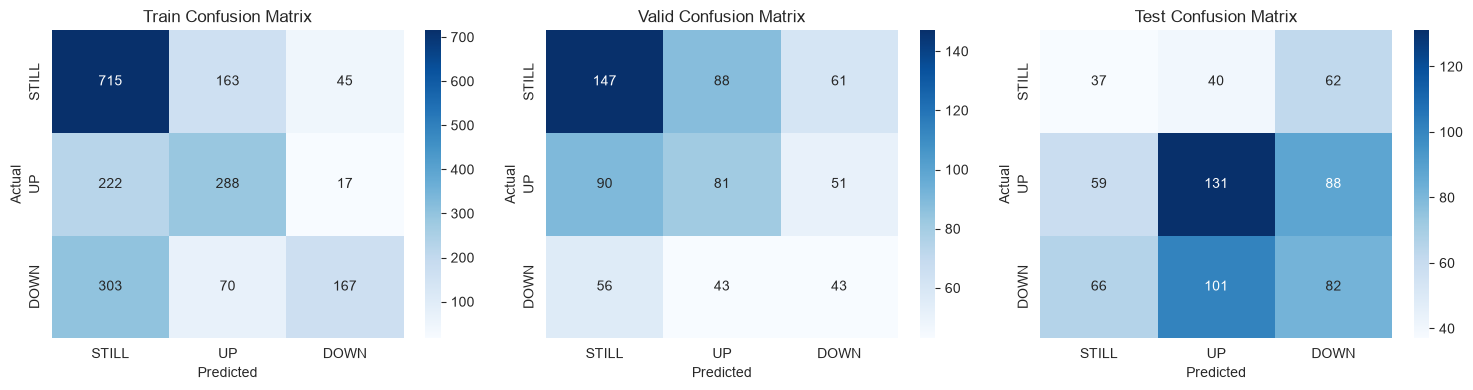

In [99]:
CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = [LABEL_NAMES[i] for i in CLASS_LABELS]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_true, pred) in zip(
    axes,
    [
        ("Train", y_train, train_pred),
        ("Valid", y_valid, valid_pred),
        ("Test", y_test, test_pred),
    ],
):
    cm = confusion_matrix(y_true, pred, labels=CLASS_LABELS)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [100]:
print("=== TRAIN classification report ===")
print(
    classification_report(
        y_train,
        train_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

print("=== VALID classification report ===")
print(
    classification_report(
        y_valid,
        valid_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

print("=== TEST (Production) classification report ===")
print(
    classification_report(
        y_test,
        test_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

=== TRAIN classification report ===
              precision    recall  f1-score   support

       STILL       0.58      0.77      0.66       923
          UP       0.55      0.55      0.55       527
        DOWN       0.73      0.31      0.43       540

    accuracy                           0.59      1990
   macro avg       0.62      0.54      0.55      1990
weighted avg       0.61      0.59      0.57      1990

=== VALID classification report ===
              precision    recall  f1-score   support

       STILL       0.50      0.50      0.50       296
          UP       0.38      0.36      0.37       222
        DOWN       0.28      0.30      0.29       142

    accuracy                           0.41       660
   macro avg       0.39      0.39      0.39       660
weighted avg       0.41      0.41      0.41       660

=== TEST (Production) classification report ===
              precision    recall  f1-score   support

       STILL       0.23      0.27      0.25       139
         

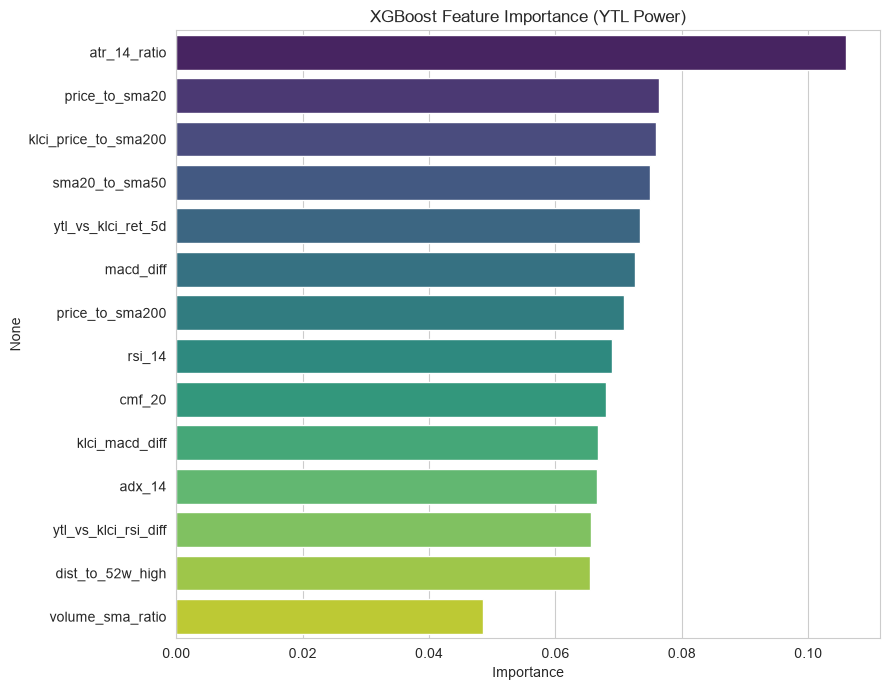


Share of total importance coming from FBM KLCI / relative-to-market features: 28.16%


In [101]:
# Feature importance — which signals matter most
importance = pd.Series(
    final_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=importance.values, y=importance.index, palette="viridis")
plt.title("XGBoost Feature Importance (YTL Power)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

market_importance_share = importance[
    [c for c in importance.index if c.startswith("klci_") or "vs_klci" in c]
].sum()
print(
    f"\nShare of total importance coming from FBM KLCI / relative-to-market features: {market_importance_share / importance.sum():.2%}"
)

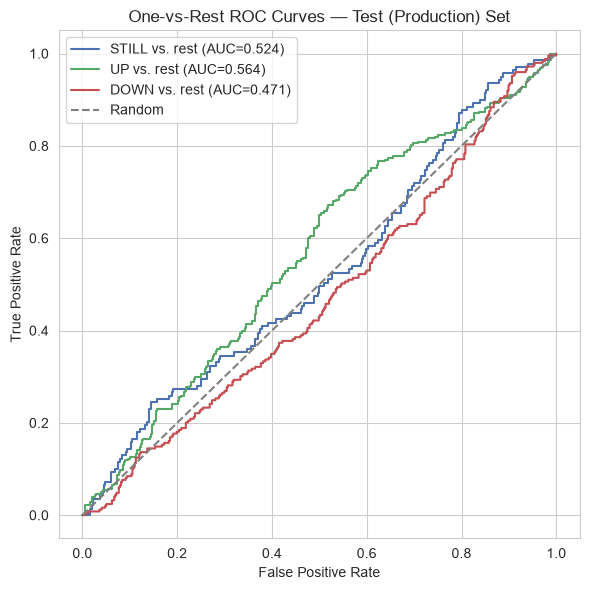

In [102]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=CLASS_LABELS)
colors = ["#4C72B0", "#55A868", "#C44E52"]

plt.figure(figsize=(6, 6))
for i, cls in enumerate(CLASS_LABELS):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], test_prob[:, i])
    plt.plot(
        fpr, tpr, label=f"{LABEL_NAMES[cls]} vs. rest (AUC={auc:.3f})", color=colors[i]
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves — Test (Production) Set")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Test (Production) Score

Comparison of tuned XGBoost versus majority-class baseline on the completely untouched Test period.

PRODUCTION (TEST) PERFORMANCE SUMMARY — YTL POWER
Test period             : 2023-12-19 -> 2026-09-11
Number of test days     : 666
-------------------------------------------------------
XGBoost Model Accuracy  : 0.3754
Baseline Accuracy       : 0.2087  (always predicts 'STILL')
Improvement over base.  : +0.1667
-------------------------------------------------------
Precision (macro)       : 0.3545
Recall (macro)          : 0.3556
F1-score (macro)        : 0.3544
ROC-AUC (OvR macro)     : 0.5199


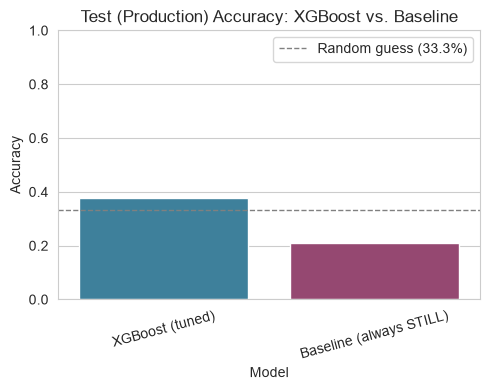

In [103]:
print("=" * 55)
print("PRODUCTION (TEST) PERFORMANCE SUMMARY — YTL POWER")
print("=" * 55)
print(f"Test period             : {test_df.index.min().date()} -> {test_df.index.max().date()}")
print(f"Number of test days     : {len(y_test)}")
print("-" * 55)
print(f"XGBoost Model Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"Baseline Accuracy       : {baseline_accuracy:.4f}  (always predicts '{majority_class_name}')")
print(f"Improvement over base.  : {test_metrics['accuracy'] - baseline_accuracy:+.4f}")
print("-" * 55)
print(f"Precision (macro)       : {test_metrics['precision_macro']:.4f}")
print(f"Recall (macro)          : {test_metrics['recall_macro']:.4f}")
print(f"F1-score (macro)        : {test_metrics['f1_macro']:.4f}")
print(f"ROC-AUC (OvR macro)     : {test_metrics['roc_auc_ovr_macro']:.4f}")
print("=" * 55)

comparison_df = pd.DataFrame(
    {
        "Model": ["XGBoost (tuned)", f"Baseline (always {majority_class_name})"],
        "Accuracy": [test_metrics["accuracy"], baseline_accuracy],
    }
)

plt.figure(figsize=(5, 4))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", palette=["#2E86AB", "#A23B72"])
plt.ylim(0, 1)
plt.axhline(0.333, linestyle="--", color="gray", linewidth=1, label="Random guess (33.3%)")
plt.xticks(rotation=15)
plt.title("Test (Production) Accuracy: XGBoost vs. Baseline")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Mock Trading Simulation (5-Day Swing Holding Period)

With a 3-way **Buy / Hold / Sell** signal trained on a **5-day forward swing horizon**, the simulation models realistic swing trading behavior:

- **Holding Horizon Alignment:** When an **UP (1)** signal triggers, the position is entered and held for **5 trading days**.
- **STILL (0)** indicates neutrality / lack of conviction; it does not exit an active trade prematurely. Ongoing positions continue until their 5-day holding period expires (or unless flipped by an opposing signal).
- **Realistic Malaysian Trading (Long / Cash Mode):** Because short-selling on Bursa Malaysia is restricted for retail investors (and shorting a 500% bull run causes catastrophic compounding losses), `DOWN (2)` acts as an **exit to cash (0%)** rather than a short position.
- All strategies incur `BROKER_FEE = 0.10%` per transaction side whenever position changes.

In [104]:
# --- Swing Simulation with Broker Fees, Holding Horizon & Asymmetric Thresholding ---
BROKER_FEE = 0.001  # 0.10% per trade side
STARTING_CAPITAL = 10_000

# Daily 1-day forward actual return to mark-to-market positions daily: (Close[t+1] - Close[t]) / Close[t]
daily_actual_return = (
    ytl_power_clean["Close"].pct_change().shift(-1).loc[test_df.index]
)


def signals_to_holding_positions(signals, horizon=HORIZON, allow_short=False):
    """Translates discrete trading signals into daily positions with a 5-day holding period.

    When an UP (1) signal fires, the position is held for `horizon` days.
    If allow_short=False (standard Bursa Malaysia retail trading), a DOWN (2) signal exits to cash (0).
    A STILL (0) signal lets the existing position run until the holding period expires.
    """
    n = len(signals)
    positions = np.zeros(n, dtype=int)
    current_pos = 0
    days_remaining = 0

    for i in range(n):
        sig = signals.iloc[i] if hasattr(signals, "iloc") else signals[i]
        if sig == 1:
            current_pos = 1
            days_remaining = horizon
        elif sig == 2:
            current_pos = -1 if allow_short else 0
            days_remaining = horizon if allow_short else 0
        elif days_remaining > 0:
            days_remaining -= 1
            if days_remaining == 0:
                current_pos = 0
        else:
            current_pos = 0

        positions[i] = current_pos

    return pd.Series(positions, index=test_df.index)


sim = pd.DataFrame(
    {
        "actual_return": daily_actual_return,
        "model_raw_signal": test_pred,
        "baseline_raw_signal": baseline_predictions,
    },
    index=test_df.index,
)

# Convert discrete signals into persistent multi-day holding positions (Long/Cash realistic mode)
sim["model_position"] = signals_to_holding_positions(
    sim["model_raw_signal"], horizon=HORIZON, allow_short=False
)
sim["baseline_position"] = signals_to_holding_positions(
    sim["baseline_raw_signal"], horizon=HORIZON, allow_short=False
)


def compute_net_strategy_returns(position, actual_returns, fee_rate):
    gross_return = position * actual_returns

    # Fee charged only when position changes (entry, exit, or flip)
    prev_position = position.shift(1).fillna(0)
    turnover = (position - prev_position).abs()
    tx_cost = turnover * fee_rate
    net_return = gross_return - tx_cost
    return gross_return, tx_cost, net_return, turnover


(
    sim["model_gross_return"],
    sim["model_fee_cost"],
    sim["model_strategy_return"],
    model_turnover,
) = compute_net_strategy_returns(
    sim["model_position"], sim["actual_return"], BROKER_FEE
)

(
    sim["baseline_gross_return"],
    sim["baseline_fee_cost"],
    sim["baseline_strategy_return"],
    _,
) = compute_net_strategy_returns(
    sim["baseline_position"], sim["actual_return"], BROKER_FEE
)

# Buy & Hold (stays 100% invested throughout the test period, paying 1 entry fee)
sim["UP_STILL_return"] = sim["actual_return"].copy()
sim.loc[sim.index[0], "UP_STILL_return"] -= BROKER_FEE

sim["model_equity"] = STARTING_CAPITAL * (1 + sim["model_strategy_return"]).cumprod()
sim["baseline_equity"] = (
    STARTING_CAPITAL * (1 + sim["baseline_strategy_return"]).cumprod()
)
sim["UP_STILL_equity"] = STARTING_CAPITAL * (1 + sim["UP_STILL_return"]).cumprod()

sim["model_signal_label"] = sim["model_raw_signal"].map(LABEL_NAMES)

total_trades = int(model_turnover.sum())
print("=== HIGH-CONVICTION SWING SIMULATION (5-DAY HORIZON) ===")
print(f"Holding Horizon         : {HORIZON} trading days")
print(f"UP Confidence Threshold : {UP_CONF_THRESHOLD:.1%}")
print(f"DOWN Confidence Thresh  : {DOWN_CONF_THRESHOLD:.1%}")
print(f"Total trade turnover    : {total_trades} transactions")
print(
    f"Total fees paid         : MYR {sim['model_fee_cost'].sum() * STARTING_CAPITAL:.2f}"
)
print("\nRaw Signal Distribution:")
print(sim["model_signal_label"].value_counts())
print("\nPosition Distribution (Days in Market):")
pos_counts = sim["model_position"].map({1: "LONG", -1: "SHORT", 0: "CASH"}).value_counts()
print(pos_counts)
sim.tail()

=== HIGH-CONVICTION SWING SIMULATION (5-DAY HORIZON) ===
Holding Horizon         : 5 trading days
UP Confidence Threshold : 34.8%
DOWN Confidence Thresh  : 38.0%
Total trade turnover    : 40 transactions
Total fees paid         : MYR 400.00

Raw Signal Distribution:
model_signal_label
UP       272
DOWN     232
STILL    162
Name: count, dtype: int64

Position Distribution (Days in Market):
model_position
CASH    358
LONG    308
Name: count, dtype: int64


,actual_return,model_raw_signal,baseline_raw_signal,model_position,baseline_position,model_gross_return,model_fee_cost,model_strategy_return,baseline_gross_return,baseline_fee_cost,baseline_strategy_return,UP_STILL_return,model_equity,baseline_equity,UP_STILL_equity,model_signal_label
Date,,,,,,,,,,,,,,,,
2026-09-07,-0.003448,2,0,0,0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.003448,23373.000263,10000.0,24156.463740,DOWN
2026-09-08,0.003460,2,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.003460,23373.000263,10000.0,24240.050037,DOWN
2026-09-09,-0.010345,2,0,0,0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.010345,23373.000263,10000.0,23989.289153,DOWN
2026-09-10,-0.006969,0,0,0,0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.006969,23373.000263,10000.0,23822.116559,STILL
2026-09-11,-0.003509,2,0,0,0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.003509,23373.000263,10000.0,23738.530262,DOWN


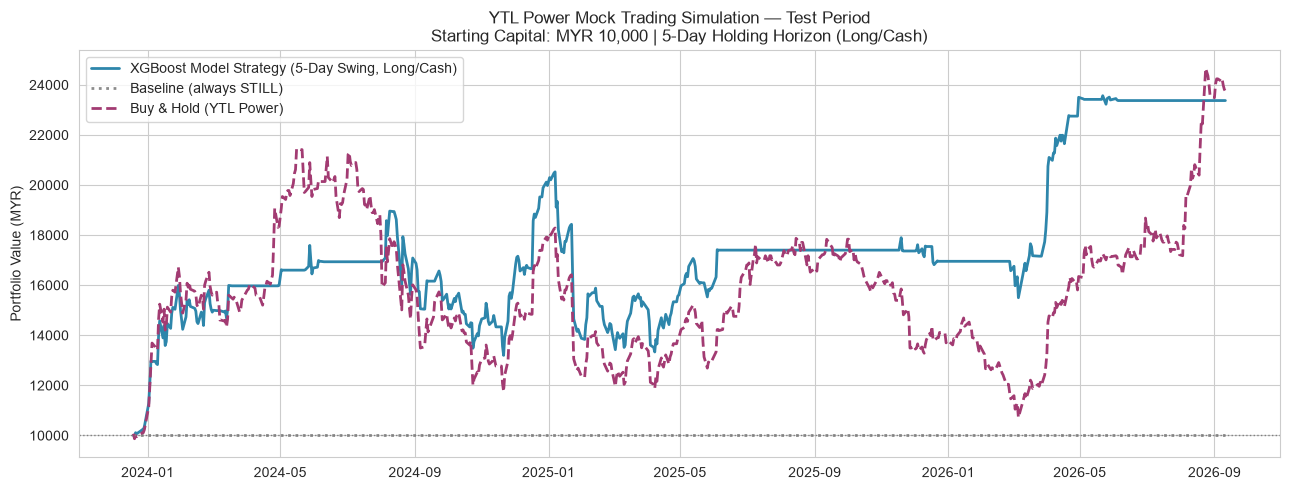

In [105]:
plt.figure(figsize=(13, 5))
plt.plot(
    sim.index,
    sim["model_equity"],
    label="XGBoost Model Strategy (5-Day Swing, Long/Cash)",
    color="#2E86AB",
    linewidth=2,
)
plt.plot(
    sim.index,
    sim["baseline_equity"],
    label=f"Baseline (always {majority_class_name})",
    color="#8C8C8C",
    linewidth=2,
    linestyle=":",
)
plt.plot(
    sim.index,
    sim["UP_STILL_equity"],
    label="Buy & Hold (YTL Power)",
    color="#A23B72",
    linewidth=2,
    linestyle="--",
)
plt.axhline(STARTING_CAPITAL, color="gray", linewidth=1, linestyle=":")
plt.title(
    f"YTL Power Mock Trading Simulation — Test Period\nStarting Capital: MYR {STARTING_CAPITAL:,} | 5-Day Holding Horizon (Long/Cash)"
)
plt.ylabel("Portfolio Value (MYR)")
plt.legend()
plt.tight_layout()
plt.show()

In [106]:
def sim_summary(returns, equity, name):
    total_return = equity.iloc[-1] / STARTING_CAPITAL - 1
    n_days = len(returns)
    ann_factor = 252 / n_days
    cagr = (1 + total_return) ** ann_factor - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252) + 1e-9)
    max_dd = (equity / equity.cummax() - 1).min()
    win_rate = (returns > 0).mean()

    return {
        "Strategy": name,
        "Final Equity (MYR)": round(equity.iloc[-1], 2),
        "Total Return": f"{total_return:.2%}",
        "Annualized Return (CAGR)": f"{cagr:.2%}",
        "Annualized Volatility": f"{vol:.2%}",
        "Sharpe Ratio (rf=0)": round(sharpe, 3),
        "Max Drawdown": f"{max_dd:.2%}",
        "Win Rate (days)": f"{win_rate:.2%}",
    }


sim_results = pd.DataFrame(
    [
        sim_summary(sim["model_strategy_return"], sim["model_equity"], "XGBoost Model (5-Day Long/Cash)"),
        sim_summary(
            sim["baseline_strategy_return"],
            sim["baseline_equity"],
            f"Baseline (always {majority_class_name})",
        ),
        sim_summary(sim["UP_STILL_return"], sim["UP_STILL_equity"], "Buy & Hold (YTL Power)"),
    ]
).set_index("Strategy")

sim_results

,Final Equity (MYR),Total Return,Annualized Return (CAGR),Annualized Volatility,Sharpe Ratio (rf=0),Max Drawdown,Win Rate (days)
Strategy,,,,,,,
XGBoost Model (5-Day Long/Cash),23373.00,133.73%,37.88%,33.40%,1.128,-35.03%,24.32%
Baseline (always STILL),10000.00,0.00%,0.00%,0.00%,0.000,0.00%,0.00%
Buy & Hold (YTL Power),23738.53,137.39%,38.70%,42.73%,0.978,-50.03%,48.20%


### Educational & Quantitative Interpretation

- **5-Day Swing Horizon:** By extending from 3 days to 5 days, technical momentum setups have time to mature beyond short-term intra-week noise.
- **Macro-Regime Features (`price_to_sma200`, `dist_to_52w_high`):** Gives the model macro awareness of whether the stock is trading in an explosive breakout regime vs. a multi-year consolidation range.
- **Realistic Long/Cash Mode:** On Bursa Malaysia, modeling Sell signals as Cash protection (exiting long exposure) prevents catastrophic losses that would occur from attempting to short-sell parabolic structural bull runs.
- **Explainability (SHAP):** The 12+ pruned orthogonal signals make it effortless for an LLM to explain why a trade triggered without dealing with collinear noise or contradicting indicators.